In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

In [31]:
def explore_column(df, col):
    """
    Explore a single column in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to explore.
    col (str): The column name to explore.
    
    Returns:
    None
    """
    # Check if the column exists in the DataFrame
    if col not in df.columns:
        print(f"Column '{col}' does not exist in the DataFrame.")
        return

    # Display basic statistics
    print(f"Statistics for column '{col}':")
    print(df[col].describe())
    print("\n")


    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    if df[col].nunique() < 10:
        print(f"Unique values in '{col}': {df[col].unique()}")
    else:
        print(f"First 10 unique values in '{col}': {df[col].unique()[:10]}")
    print("\n")
    
    # Display missing values
    missing_values = df[col].isnull().sum()
    print(f"Missing values in '{col}': {missing_values}")
    print(f"Percentage of missing values in '{col}': {missing_values / len(df) * 100:.2f}%")


            
    # Plot the distribution of the column
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [32]:
df = pd.read_csv('data/training_set_VU_DM.csv')
df["date_time"] = pd.to_datetime(df["date_time"])


Statistics for column 'booking_bool':
count    4.958347e+06
mean     2.791051e-02
std      1.647165e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: booking_bool, dtype: float64


Number of unique values in 'booking_bool': 2
Unique values in 'booking_bool': [0 1]


Missing values in 'booking_bool': 0
Percentage of missing values in 'booking_bool': 0.00%


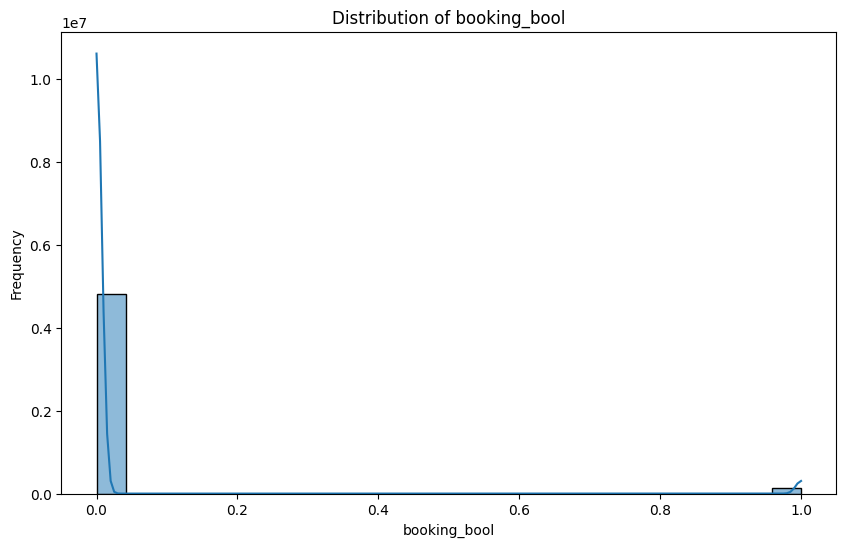

In [33]:
explore_column(df, "booking_bool")

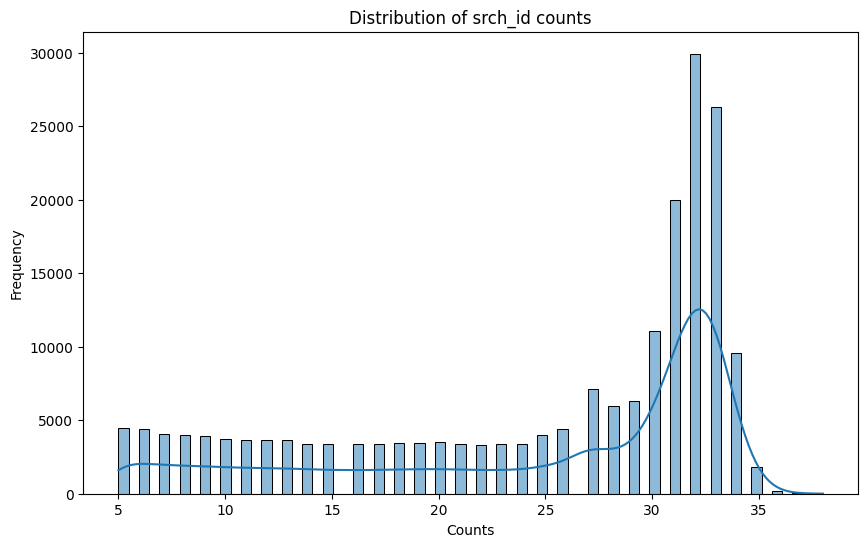

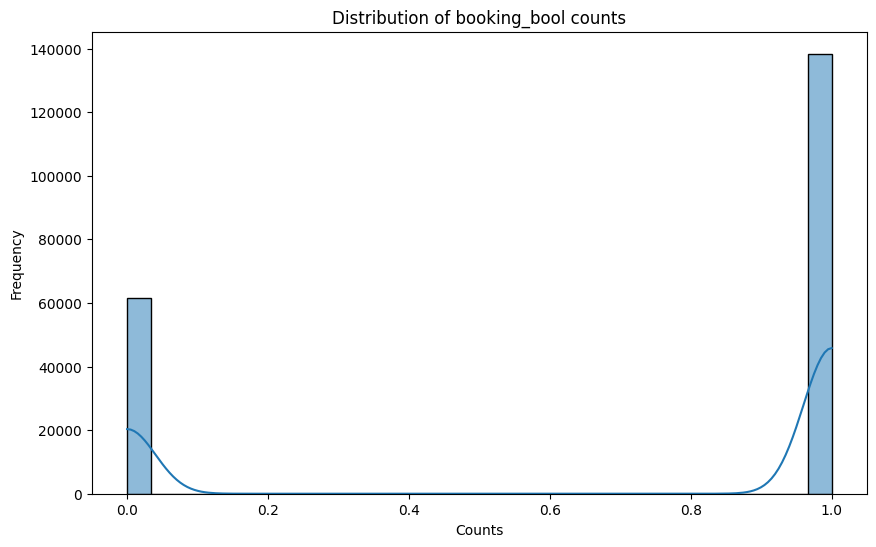

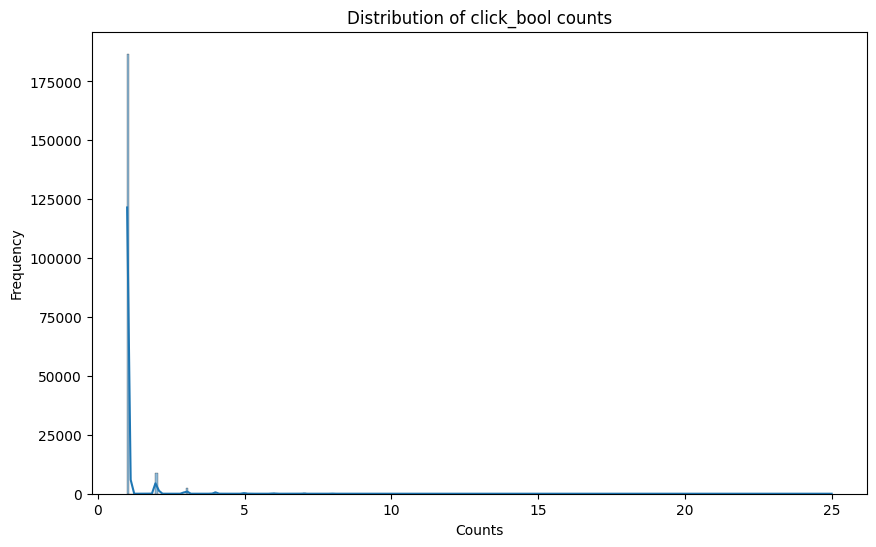

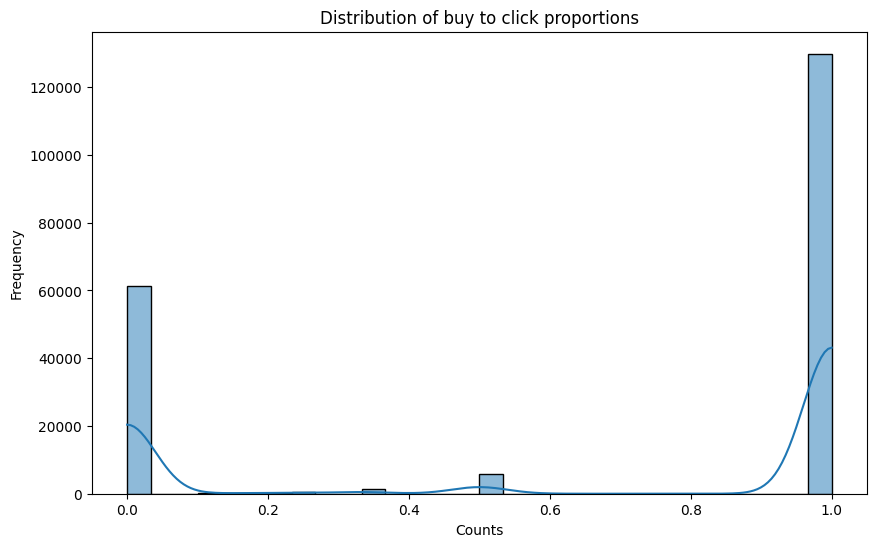

Unique counts of click_bool and their frequencies:
click_bool
1     186764
2       8772
3       2281
4        900
5        426
6        279
7        144
8         88
9         47
11        27
10        20
13        10
12        10
14         7
16         7
15         6
20         2
17         2
24         1
19         1
25         1
Name: count, dtype: int64
Unique counts of click_bool: [ 1  3  2  6  7  5  9 19 11 10  4  8 15 13 12 24 14 20 17 16 25]


In [34]:
# count how many rows groupped by srch_id



srch_id_counts = df.groupby("srch_id").size().reset_index(name="counts")
srch_id_counts
# in each group, count how many rows have booking_bool == 1
srch_id_counts["booking_bool"] = df.groupby("srch_id")["booking_bool"].sum().values
srch_id_counts["click_bool"] = df.groupby("srch_id")["click_bool"].sum().values

# create a column dividing booking_bool by click_count
srch_id_counts["booking_bool_prop"] = srch_id_counts["booking_bool"] / srch_id_counts["click_bool"]



# plot the distribution of srch_id counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["counts"], kde=True)
plt.title("Distribution of srch_id counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# plot the distribution of booking_bool counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["booking_bool"], kde=True)
plt.title("Distribution of booking_bool counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# plot the distribution of click_bool counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["click_bool"], kde=True, bins=300)
plt.title("Distribution of click_bool counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["booking_bool_prop"], kde=True)
plt.title("Distribution of buy to click proportions")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# print unique counts of click_bool and their frequencies
click_bool_counts = srch_id_counts["click_bool"].value_counts()
print("Unique counts of click_bool and their frequencies:")
print(click_bool_counts)
print(f"Unique counts of click_bool: {srch_id_counts['click_bool'].unique()}")

In [58]:
df["target"] = np.where(df["click_bool"] == 1, 1, 0)
df["target"] = np.where(df["booking_bool"] == 1, 5, df["target"])


# check the distribution of target
target_counts = df["target"].value_counts()
print("Distribution of target:")
print(target_counts)

df.columns


Distribution of target:
target
0    4736468
5     138390
1      83489
Name: count, dtype: int64


Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

In [73]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit

# 1. Prepare splits with srch_id retained
feature_cols = [c for c in df.columns
                if c not in ['srch_id','target','click_bool',
                             'booking_bool','date_time','gross_bookings_usd', "position"]]
X = df[feature_cols].copy()
X['srch_id'] = df['srch_id']
y = df['target']
groups = df['srch_id']

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
X_val   = X.iloc[test_idx].reset_index(drop=True)
y_val   = y.iloc[test_idx].reset_index(drop=True)

# 2. Compute group sizes correctly
group_train = X_train.groupby('srch_id').size().to_list()
group_val   = X_val.groupby('srch_id').size().to_list()
assert sum(group_train) == len(X_train)
assert sum(group_val)   == len(X_val)

# 3. Drop the query column for training
X_train_feats = X_train.drop(columns=['srch_id'])
X_val_feats   = X_val.drop(columns=['srch_id'])

# 4. Create LightGBM Datasets with proper group counts
lgb_train = lgb.Dataset(X_train_feats, label=y_train, group=group_train)
lgb_eval  = lgb.Dataset(X_val_feats,   label=y_val,   group=group_val,
                       reference=lgb_train)

# 5. Train
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [5],
    # … your hyperparameters …
}
gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_train, lgb_eval],
    valid_names=['train','valid'])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.219887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4259
[LightGBM] [Info] Number of data points in the train set: 3966682, number of used features: 48


In [74]:
from sklearn.metrics import ndcg_score
import numpy as np

# 1. Predict scores
y_pred = gbm.predict(X_val_feats)

# 2. Split true & pred by query groups
boundaries = np.cumsum(group_val)[:-1]
y_true_splits = np.split(y_val, boundaries)
y_pred_splits = np.split(y_pred, boundaries)

# 3. Compute per-query NDCG@5 and average
ndcgs = [
    ndcg_score([true], [pred], k=5)
    for true, pred in zip(y_true_splits, y_pred_splits)
]
print("NDCG@5:", np.mean(ndcgs))


/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


NDCG@5: 0.37793072354444346


                 feature  split_importance  gain_importance
10  prop_location_score2               332    231864.402458
12             price_usd               579    116966.237949
5                prop_id                50     69072.262209
9   prop_location_score1               278     56845.867666
6        prop_starrating               270     55356.434229


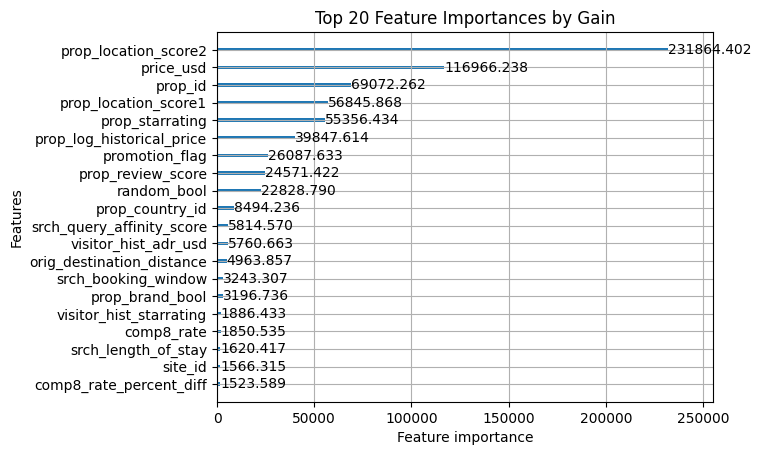

In [76]:
# `gbm` is your trained Booster
# Importance by number of splits:
split_imp = gbm.feature_importance(importance_type='split')

# Importance by total gain:
gain_imp  = gbm.feature_importance(importance_type='gain')

# Get feature names in the same order
feature_names = gbm.feature_name()

# Combine into a DataFrame
import pandas as pd
df_imp = pd.DataFrame({
    'feature': feature_names,
    'split_importance': split_imp,
    'gain_importance':  gain_imp
}).sort_values('gain_importance', ascending=False)
print(df_imp.head())


import lightgbm as lgb
import matplotlib.pyplot as plt

# Plot top 20 features by gain
ax = lgb.plot_importance(
    gbm,
    max_num_features=20,
    importance_type='gain',
    title='Top 20 Feature Importances by Gain'
)
plt.show()


### bool preedictions

In [37]:
# train-test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=["booking_bool", "click_bool", "gross_bookings_usd", "srch_id", "date_time", "position"])
y1 = df["booking_bool"]
y2 = df["click_bool"]
y3 = df["gross_bookings_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)
# X_train, X_test, y_train3, y_test3 = train_test_split(X, y3, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3966677, 49)
X_test shape: (991670, 49)
y_train shape: (3966677,)
y_test shape: (991670,)


In [38]:

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train,
)


# Train the model
model_book = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_click = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# Fit the model
model_book.fit(X_train, y_train, sample_weight=sample_weights)
model_click.fit(X_train, y_train2, sample_weight=sample_weights)



/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:53:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:53:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

                Model  Accuracy  F1 Score  Precision  Recall  ROC AUC
0  Booking Bool Model       1.0       1.0        1.0     1.0      1.0
1    Click Bool Model       1.0       1.0        1.0     1.0      1.0


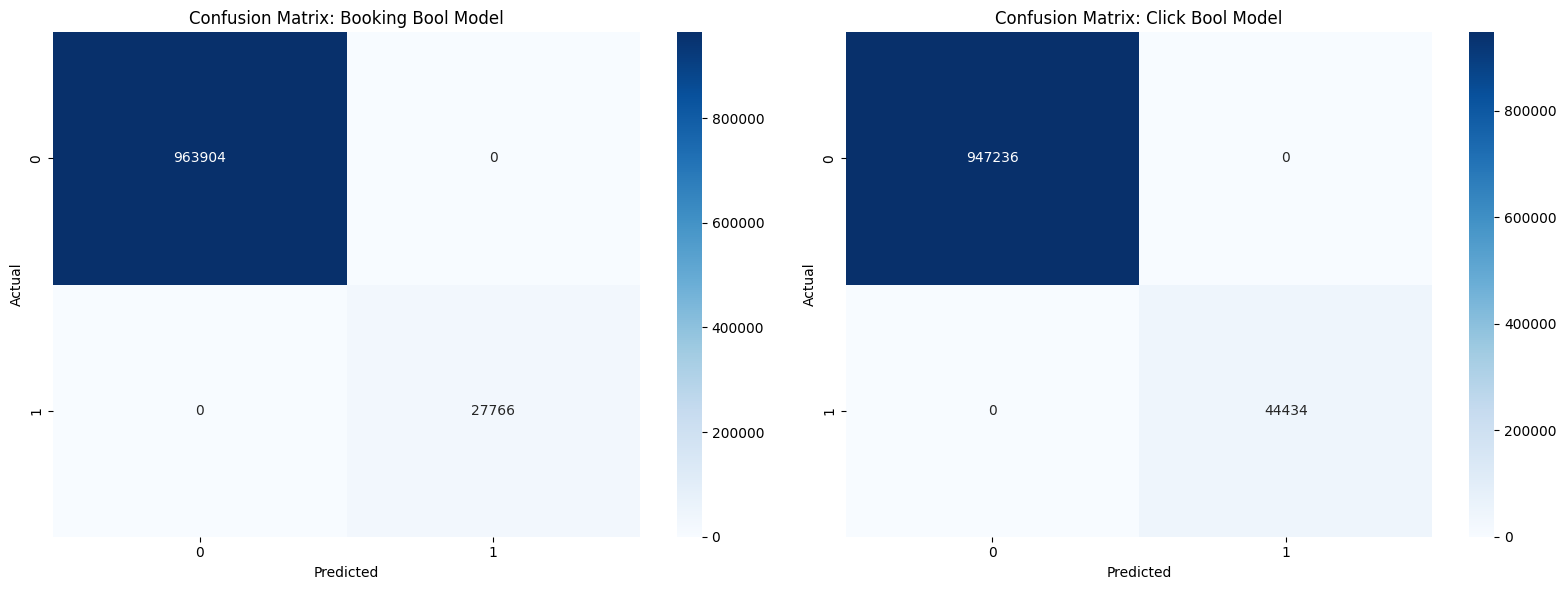

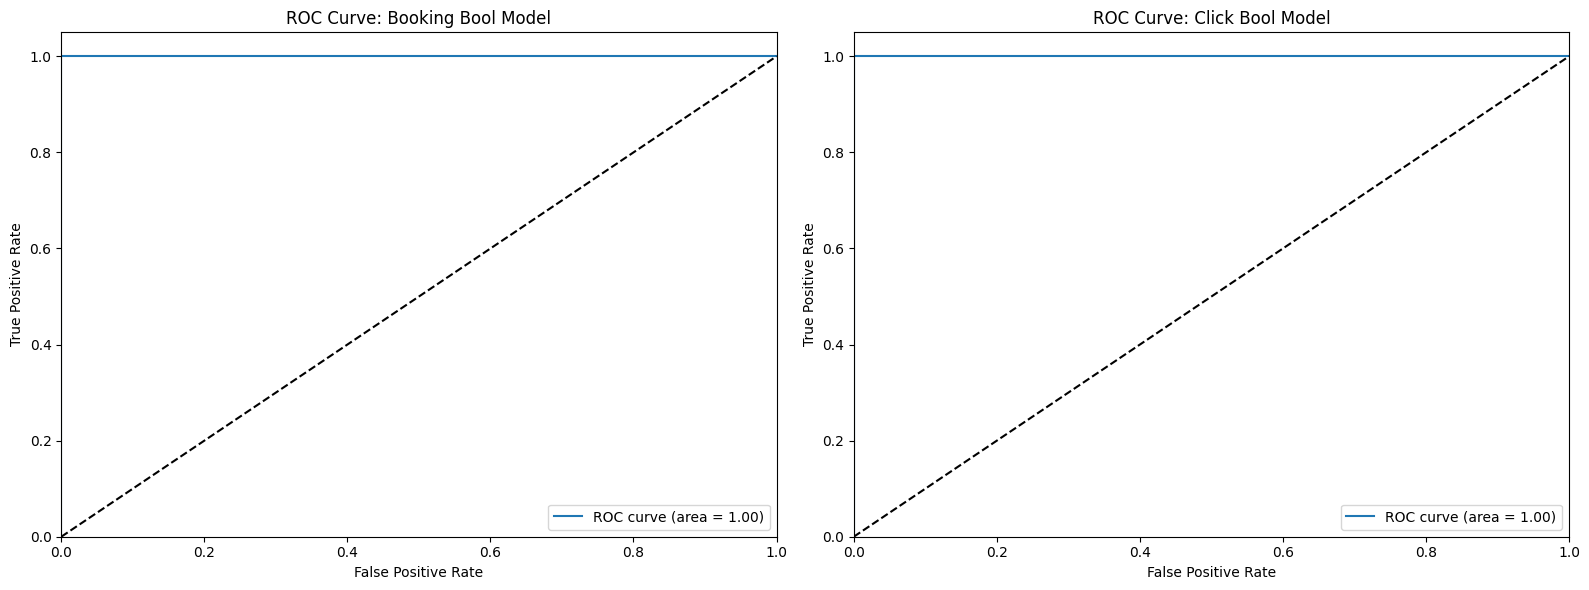

/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_97585/2865987714.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_97585/2865987714.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


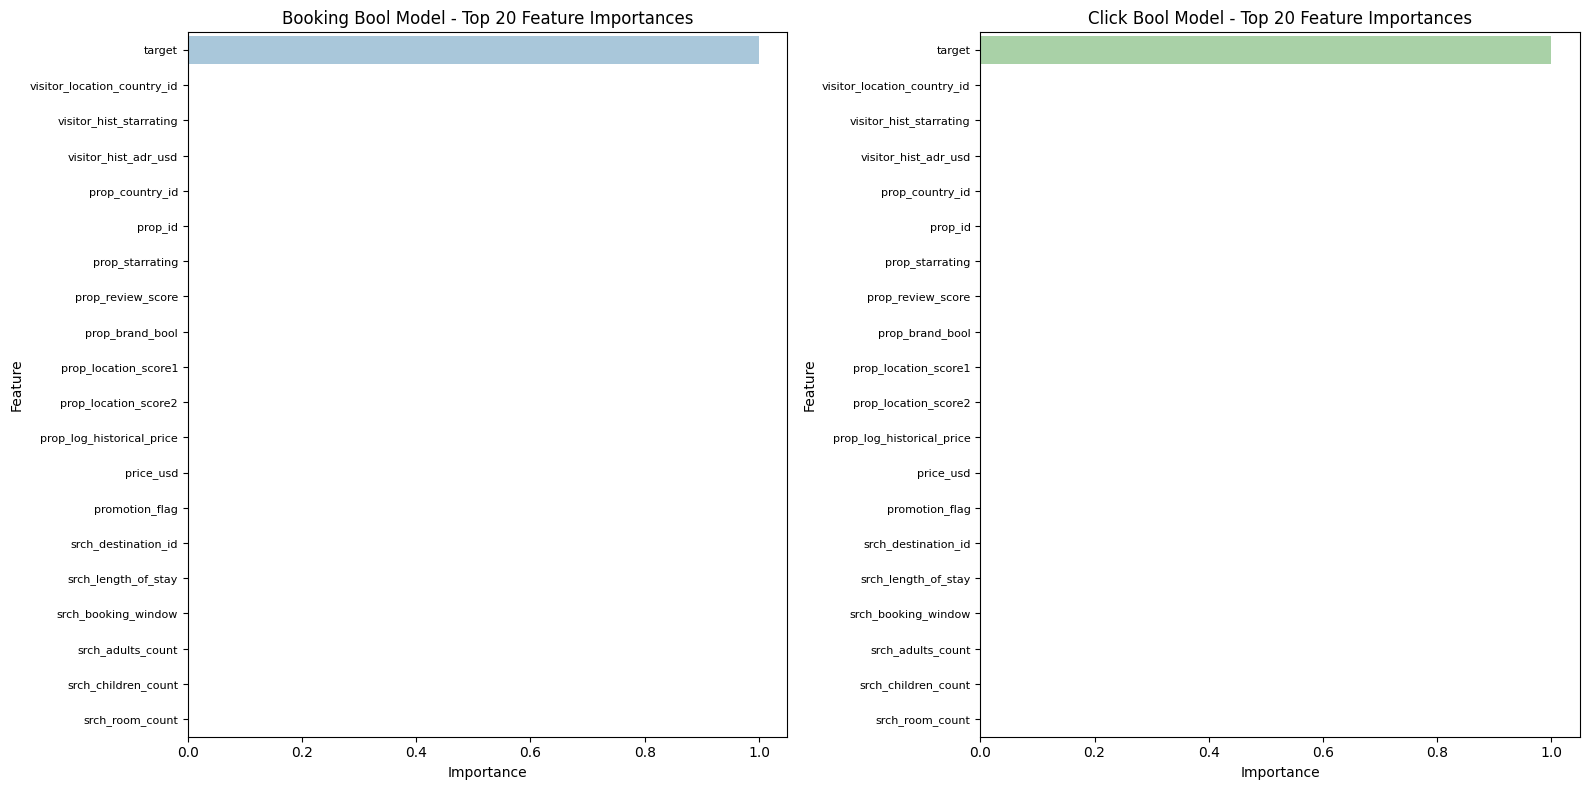

In [39]:
# Make predictions
y_pred = model_book.predict(X_test)
y_pred2 = model_click.predict(X_test)

# Evaluate the models
metrics = {
    "Model": ["Booking Bool Model", "Click Bool Model"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test2, y_pred2)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test2, y_pred2)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test2, y_pred2)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test2, y_pred2)],
    "ROC AUC": [roc_auc_score(y_test, y_pred), roc_auc_score(y_test2, y_pred2)],
}

# Print metrics
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix: Booking Bool Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix: Click Bool Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Plot ROC curves side by side
y_pred_proba_book = model_book.predict_proba(X_test)[:, 1]
y_pred_proba_click = model_click.predict_proba(X_test)[:, 1]

fpr_book, tpr_book, _ = roc_curve(y_test, y_pred_proba_book)
fpr_click, tpr_click, _ = roc_curve(y_test2, y_pred_proba_click)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(fpr_book, tpr_book, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba_book))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Booking Bool Model')
axes[0].legend(loc='lower right')

axes[1].plot(fpr_click, tpr_click, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test2, y_pred_proba_click))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Click Bool Model')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Feature importance
importance_book = model_book.feature_importances_
importance_click = model_click.feature_importances_
feature_names = X.columns
importance_df_book = pd.DataFrame(importance_book, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)
importance_df_click = pd.DataFrame(importance_click, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)


# Prepare sorted DataFrames for top features (make feature names a column)
feat_imp_book = (
  importance_df_book
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

feat_imp_click = (
  importance_df_click
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_book,
    ax=axes[0], palette="Blues_d"
)
axes[0].set_title("Booking Bool Model - Top 20 Feature Importances")
axes[0].tick_params(axis="y", labelsize=8)

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_click,
    ax=axes[1], palette="Greens_d"
)
axes[1].set_title("Click Bool Model - Top 20 Feature Importances")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()
